In [1]:
from google.colab import files
files.upload()

KeyboardInterrupt: 

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip skin-cancer-mnist-ham10000.zip

Streaming output truncated to the last 5000 lines.
  inflating: ham10000_images_part_2/ISIC_0029325.jpg  
  inflating: ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: ham10000_images_part_2/ISIC_0029337.jpg  
  inflating: ham10000_images_part_2/ISIC_0029338.jpg  
  inflating: ham10000_images_part_2/ISIC_0029339.jpg  
  inflating: ham10000_images_part_2/ISIC_0029340.jpg  
  inflating: ham10000_images_part_2/ISIC_0029341.jpg  
  inflating: h

Prepare Data

In [4]:
import pandas as pd
import os
import shutil

df = pd.read_csv("HAM10000_metadata.csv")

# Binary classification: melanoma vs benign
df['label'] = df['dx'].apply(lambda x: 1 if x == 'mel' else 0)

image_dir1 = "HAM10000_images_part_1"
image_dir2 = "HAM10000_images_part_2"

def get_image_path(image_id):
    if os.path.exists(os.path.join(image_dir1, image_id + ".jpg")):
        return os.path.join(image_dir1, image_id + ".jpg")
    else:
        return os.path.join(image_dir2, image_id + ".jpg")

df['path'] = df['image_id'].apply(get_image_path)

Train-Val Split + Imbalance Handling

In [5]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'])

# Class weights
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.562482448750351), 1: np.float64(4.501123595505618)}


In [34]:
import os
import shutil

final_dir = "/content/all_images"
os.makedirs(final_dir, exist_ok=True)

folders = [
    "/content/HAM10000_images_part_1",
    "/content/HAM10000_images_part_2",
    "/content/ham10000_images_part_1",
    "/content/ham10000_images_part_2"
]

count = 0

for folder in folders:
    if os.path.exists(folder):
        for img in os.listdir(folder):
            src = os.path.join(folder, img)
            dst = os.path.join(final_dir, img)

            if not os.path.exists(dst):  # avoid duplicates
                shutil.copy(src, dst)
                count += 1

print("Total images collected:", count)

Total images collected: 10015


In [7]:
import numpy as np

print("Original Class Weights:", class_weights)

# --- FIX LOGIC ---
fixed_class_weights = {}

for k, v in class_weights.items():
    v = float(v)

    # Clip extreme weights (avoid instability)
    if v > 3.0:
        v = 3.0

    # Ensure minimum weight
    if v < 1.0:
        v = 1.0

    fixed_class_weights[k] = v

print("Fixed Class Weights:", fixed_class_weights)

Original Class Weights: {0: np.float64(0.562482448750351), 1: np.float64(4.501123595505618)}
Fixed Class Weights: {0: 1.0, 1: 3.0}


DATA GENERATOR

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='label',
    target_size=(224,224),
    batch_size=32,
    class_mode='raw'
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='label',
    target_size=(224,224),
    batch_size=32,
    class_mode='raw'
)

Found 8012 validated image filenames.
Found 2003 validated image filenames.


Mobile Net V2 MODEL

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

training ------------------------------------------------------>

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 218s 784ms/step - accuracy: 0.6866 - loss: 0.7135 - recall: 0.7112 - val_accuracy: 0.6655 - val_loss: 0.6420 - val_recall: 0.7848 - learning_rate: 0.0010
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 581ms/step - accuracy: 0.7193 - loss: 0.5542 - recall: 0.7674 - val_accuracy: 0.7064 - val_loss: 0.5729 - val_recall: 0.7623 - learning_rate: 0.0010
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 148s 589ms/step - accuracy: 0.7322 - loss: 0.5006 - recall: 0.8112 - val_accuracy: 0.6745 - val_loss: 0.6106 - val_recall: 0.8206 - learning_rate: 0.0010
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 583ms/step - accuracy: 0.7460 - loss: 0.4611 - recall: 0.8135 - val_accuracy: 0.7329 - val_loss: 0.5123 - val_recall: 0.7578 - learning_rate: 0.0010
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 147s 585ms/step - accuracy: 0.7576 - loss: 0.4465 - recall: 0.8056 - val_accuracy: 0.6880 - val_loss: 0.5851 - val_recall: 0.8386 - learning_rate: 0.0010


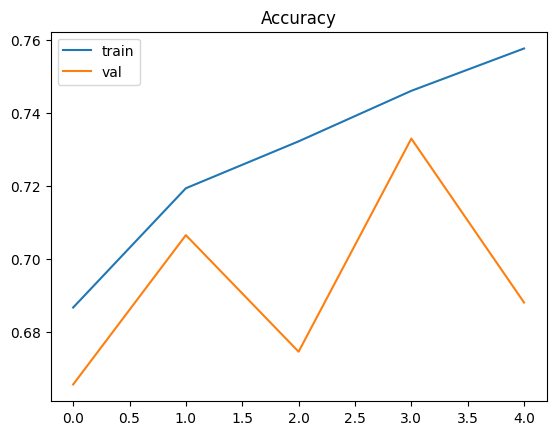

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.title("Accuracy")
plt.show()

Grad-CAM (Explainable AI)

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

last_conv_layer = "Conv_1"  # MobileNetV2 last conv layer

grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer).output, model.output]
)

def get_gradcam(img_array):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap.numpy()

VISUALIZATION OF GRAD-CAM


In [14]:
def show_gradcam(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img_array = np.expand_dims(img/255.0, axis=0)

    heatmap = get_gradcam(img_array)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    superimposed = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 0.6, superimposed, 0.4, 0)

    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Grad-CAM")
    plt.show()

SAVING MODEL

In [15]:
model.save("skin_cancer_mobilenet.h5")

In [25]:
import cv2
import numpy as np

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))

    img_float = img.astype("float32") / 255.0  # for model
    img_array = np.expand_dims(img_float, axis=0)

    return img, img_array   # return ORIGINAL + normalized

In [26]:
def predict_image(img_path):
    original_img, img_array = preprocess_image(img_path)

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        label = "Melanoma (Cancer)"
        confidence = prediction
    else:
        label = "Benign (Non-Cancer)"
        confidence = 1 - prediction

    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.4f}")

    return original_img, img_array, label

In [27]:
last_conv_layer = "Conv_1"

grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[model.get_layer(last_conv_layer).output, model.output]
)

def generate_gradcam(img_array):
    img_tensor = tf.convert_to_tensor(img_array)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [28]:
import matplotlib.pyplot as plt

def show_result(img_path):
    original_img, img_array, label = predict_image(img_path)

    heatmap = generate_gradcam(img_array)

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (224,224))

    # Convert to 0–255 uint8 (IMPORTANT FIX)
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Convert original image to same dtype (IMPORTANT FIX)
    original_img_uint8 = original_img.astype("uint8")

    # Overlay (NOW WORKS ✅)
    superimposed_img = cv2.addWeighted(
        original_img_uint8, 0.6,
        heatmap_colored, 0.4,
        0
    )

    # Show images
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Heatmap")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(label)
    plt.axis('off')

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction: Benign (Non-Cancer)
Confidence: 0.8554


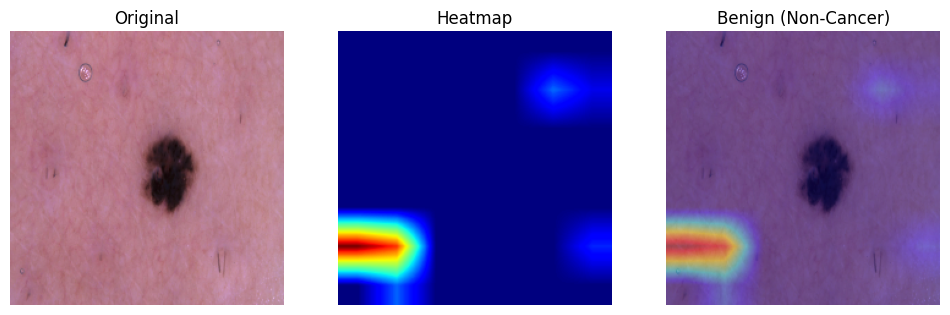

In [33]:
img_path = "/content/ham10000_images_part_2/ISIC_0029313.jpg"
show_result(img_path)